In [2]:
# ==========================================
# E-Commerce Data Analysis Project
# Author: Rui Cristovam
# Description: SQL + Python analysis using SQLAlchemy
# ==========================================


In [3]:
!pip install pymysql

In [4]:

import pandas as pd
from sqlalchemy import create_engine

# 1. Credentials Configuration
user = "root"
password = ""  # Se tiveres password, coloca-a aqui
host = "localhost"
database = "ecommerce_project"

# 2. Create SQLAlchemy Engine
# The 'mysql+pymysql' prefix is the recommended standard for MySQL connections
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")

print("Ligação via SQLAlchemy: OK")

# 3. SQL Query for Data Extraction
query = """
SELECT 
    o.order_purchase_timestamp,
    p.payment_value,
    c.customer_state
FROM orders o
JOIN order_payments p ON o.order_id = p.order_id
JOIN customers c ON o.customer_id = c.customer_id
"""

# 4. Load Data using the engine
df = pd.read_sql(query, engine)

# 5. Data Preprocessing: Convert timestamp to datetime objects
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Displaying initial results
print(f"Dados carregados: {len(df)} linhas.")
df.head()

Ligação via SQLAlchemy: OK
Dados carregados: 103886 linhas.


,order_purchase_timestamp,payment_value,customer_state
0,2017-07-29 20:08:40,342.56,MG
1,2017-03-10 20:04:32,130.22,SP
2,2017-04-23 18:13:00,208.41,SP
3,2018-03-07 15:32:34,67.42,SP
4,2017-02-20 19:21:23,232.05,RJ


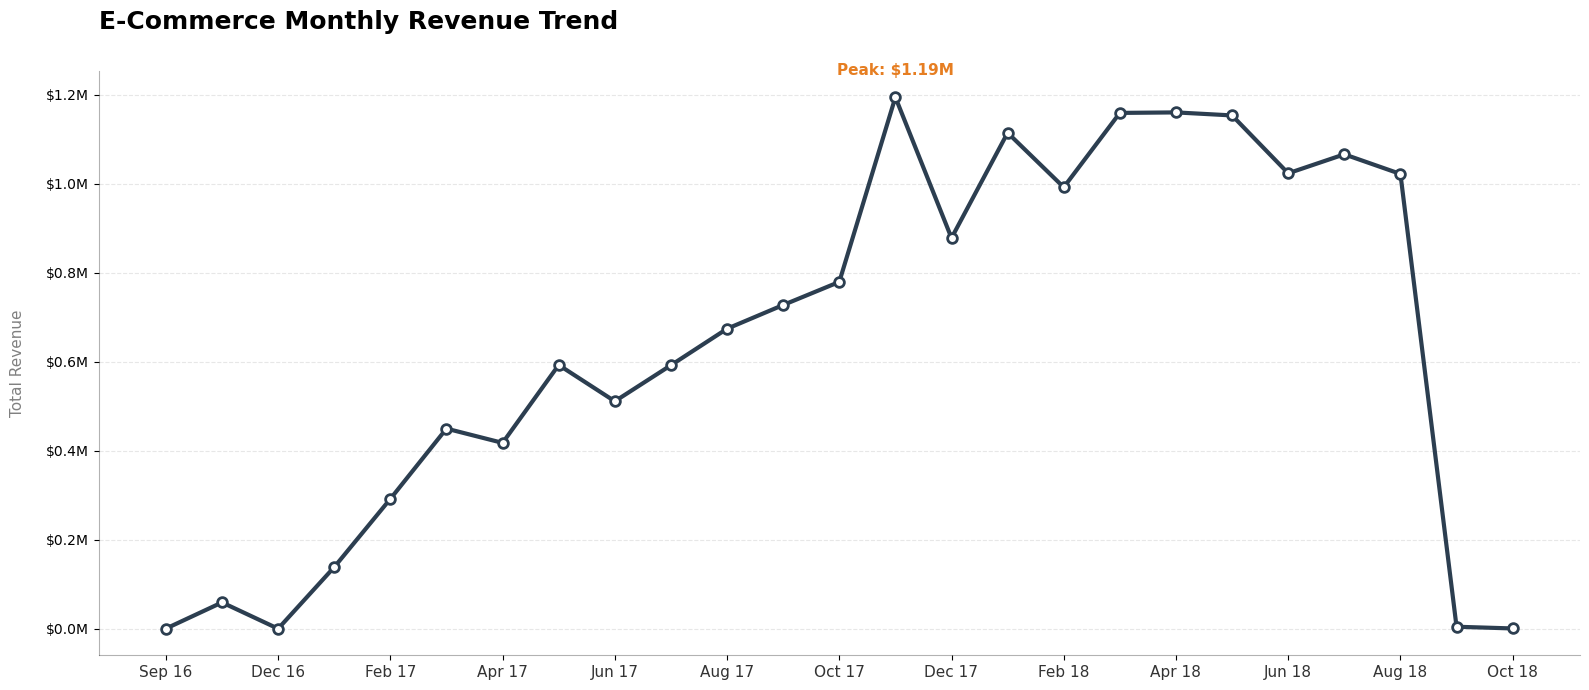

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# --- 1. Data Preparation ---
# Sort by date and create a monthly period column
df_sorted = df.sort_values('order_purchase_timestamp')
df_sorted['month_year_dt'] = df_sorted['order_purchase_timestamp'].dt.to_period('M')

# Aggregate total revenue per month
monthly_revenue = df_sorted.groupby('month_year_dt')['payment_value'].sum().reset_index()

# Formatting labels for the X-axis (e.g., "Jan 17")
monthly_revenue['month_label'] = monthly_revenue['month_year_dt'].dt.strftime('%b %y')

# --- 2. Chart Creation ---
plt.figure(figsize=(16, 7), facecolor='white')
ax = plt.gca()

plt.plot(monthly_revenue['month_label'], monthly_revenue['payment_value'], 
         color='#2c3e50', linewidth=3, marker='o', markersize=7, 
         markerfacecolor='white', markeredgewidth=2)

# --- 3. X-Axis Strategy (Optimizing readability) ---
# Displaying only 1 out of every 2 months to provide more visual space
ticks_to_show = range(0, len(monthly_revenue), 2)
labels_to_show = [monthly_revenue['month_label'][i] for i in ticks_to_show]

plt.xticks(ticks_to_show, labels_to_show, fontsize=11, color='#333333', rotation=0)

# --- 4. Aesthetics & Formatting ---
plt.title('E-Commerce Monthly Revenue Trend', fontsize=18, pad=30, loc='left', fontweight='bold')
plt.ylabel('Total Revenue', fontsize=11, color='gray', labelpad=15)

# Y-Axis Formatting (Transforming values to Millions $)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)
plt.yticks(fontsize=10)

# Visual Cleanup: Removing borders and adding subtle grids
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Highlight: Peak Value Annotation
max_val = monthly_revenue['payment_value'].max()
max_idx = monthly_revenue['payment_value'].idxmax()
plt.text(max_idx, max_val + 50000, f'Peak: ${max_val/1e6:.2f}M', 
         ha='center', fontweight='bold', color='#e67e22', fontsize=11)

plt.tight_layout()
plt.show()


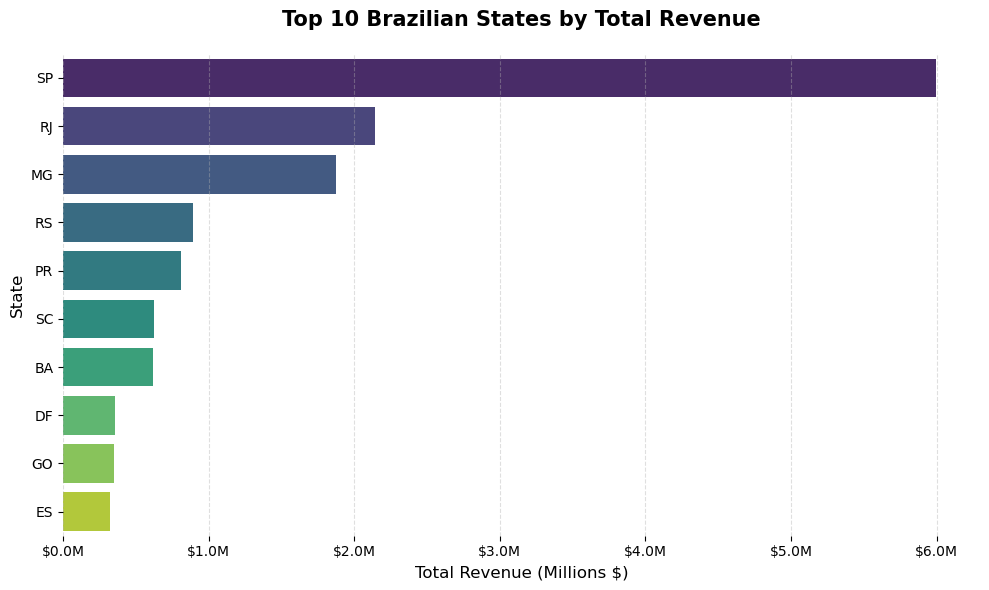

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Data Preparation: Group by state and calculate top 10 by total revenue
state_revenue = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).head(10)

# 2. Chart Configuration
plt.figure(figsize=(10, 6))

# Utilizing 'hue' and 'legend=False' to ensure compatibility with modern Seaborn versions
ax = sns.barplot(
    x=state_revenue.values, 
    y=state_revenue.index, 
    hue=state_revenue.index, 
    palette='viridis', 
    legend=False
)

# 3. Aesthetics & Titles
plt.title('Top 10 Brazilian States by Total Revenue', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Total Revenue (Millions $)', fontsize=12)
plt.ylabel('State', fontsize=12)

# 4. X-Axis Formatting: Convert large numbers to Millions ($M) format
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
ax.xaxis.set_major_formatter(formatter)

# Visual Cleanup
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 📈 Strategic Business Insights: E-Commerce Performance

### 1. Revenue Dynamics & Seasonality
* **Black Friday Catalyst:** The massive spike in **November 2017** confirms that the operation is highly reactive to major promotional events. This suggests a need for robust inventory planning 3 months prior to Q4.
* **Consistent Growth:** Beyond seasonal peaks, the month-over-month uptrend (2017-2018) shows healthy market expansion and increasing customer lifetime value.

### 2. Geographical Dominance & Expansion
* **The Southeast Hub:** **São Paulo (SP)** is the primary revenue driver. While this shows strength, it also represents a regional dependency risk.
* **Strategic Recommendation:** Optimize logistics and "Last Mile" delivery in SP, RJ, and MG to protect margins, while piloting targeted acquisition campaigns in Southern states to diversify the revenue base.

### 3. Hourly Sales Velocity
* **Prime Time Windows:** Orders peak between **10:00–12:00** and **19:00–21:00**. 
* **Tactical Application:** Marketing spend (ads, emails, push notifications) should be concentrated 30 to 60 minutes before these peak windows to maximize the Conversion Rate (CR).

---
**Executive Summary:** The business is in a strong growth phase. Future success depends on maintaining the momentum in the Southeast while leveraging data-driven marketing timing to optimize the return on advertising spend (ROAS).